<a href="https://colab.research.google.com/github/LP-D/claude/blob/main/notebooks/production/VIX_PORTFOLIO_SIM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VIX Portfolio Simulation v1 — carry, trend, congestion, avec la prédiction VIX en overlay de risque

**Rôle.** Nouveau notebook de recherche, indépendant, à lancer après `VIX_FINAL_FEATURES`. Va plus
loin que tous les notebooks précédents : au lieu de mesurer F1_dir/F1_UP_FORT dans l'abstrait, il
utilise la prédiction du modèle GLOBAL RandomForest (h=5j, N=8, SMOTE — la config de référence de
ce projet) comme **signal de gestion du risque** au sein d'un portefeuille simulé combinant trois
stratégies classiques liées au VIX :

1. **Carry** (portage) : harvester la décroissance du contango en étant court VXX quand la
   structure par terme du VIX est en contango — coupé quand le modèle anticipe un UP_FORT.
2. **Trend** (suivi de tendance) : position S&P 500 dans le sens de sa moyenne mobile 200 jours —
   réduite de moitié quand le modèle anticipe un mouvement FORT (up ou down) du VIX.
3. **Congestion** (retour à la moyenne) : stratégie contrarian à court terme, active uniquement en
   régime CALM et **seulement** quand le modèle n'anticipe pas de mouvement FORT (une vraie
   cassure invaliderait l'hypothèse de range).

**Honnêteté walk-forward** : contrairement à `VIX_PRODUCTION` (qui entraîne sur 100% de
l'historique pour le déploiement), ce notebook **régénère ses propres prédictions hors-échantillon**
en ré-exécutant le protocole walk-forward à 5 folds déjà validé (même feature pool, mêmes
hyperparamètres) et ne backteste QUE sur les périodes de test de ces folds (~60% de l'historique,
celui non utilisé pour l'entraînement d'un fold donné) — jamais sur une prédiction que le modèle
n'aurait pas pu connaître au moment T.

**Le test le plus intéressant** : une version *ablation* du même portefeuille, sans l'overlay ML
(règles fixes uniquement), pour isoler honnêtement l'apport réel de la prédiction VIX — plutôt que
de supposer qu'elle aide.

**Objectif pédagogique.** Ce notebook est aussi pensé comme support d'apprentissage : chaque
stratégie a sa cellule de théorie (mécanisme, intuition, littérature), et les métriques de
performance (Sharpe, Sortino, Calmar, drawdown) sont expliquées avant d'être calculées.

**Comparateurs** : achat-conservation du S&P 500 sur la même période, et portefeuille "naïf" (les
3 stratégies sans overlay ML) — pour juger si l'ajout du modèle apporte quelque chose de réel.


In [1]:
import subprocess, sys
pkgs = ['xgboost', 'shap', 'imbalanced-learn', 'pyarrow', 'yfinance', 'xlsxwriter', 'matplotlib']
subprocess.run([sys.executable,'-m','pip','install','-q']+pkgs, check=False)
print("Installation OK")


Installation OK


In [2]:
import os, time, json, warnings, random
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import yfinance as yf
import shap
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

SEED = 42; random.seed(SEED); np.random.seed(SEED)

NOTEBOOK_NAME = 'VIX_PORTFOLIO_SIM'
NOTEBOOK_VERSION = 'v1'

CONFIG = {
    'flat_thr': 0.003,
    'horizon': 5,
    'N': 8,
    'sampler': 'SMOTE',
    'algo': 'RandomForest',
    'n_wf_folds': 5,
    'min_train_frac': 0.40,   # doit matcher VIX_FINAL_FEATURES
    'shap_sample': 500,
    'pool_prefilter': 450,
    'min_train_rows': 100, 'min_test_rows': 20,
    'trend_ma_window': 200,
    'congestion_lookback': 5,     # rendement court terme utilisé pour le signal contrarian
    'sleeve_weights': {'carry': 1/3, 'trend': 1/3, 'congestion': 1/3},
    'trend_derisk_factor': 0.5,   # exposition trend réduite quand un mouvement FORT est anticipé
    'tickers': {'SPX': '^GSPC', 'VXX': 'VXX'},
}
TARGET_COL = 'VIX_Amplitude_Class'
GITHUB_REPO = 'LP-D/claude'
FEATURES_BRANCH = 'results/vix-final-features'
RESULTS_BRANCH = 'results/vix-portfolio-sim'

print(f"{NOTEBOOK_NAME} {NOTEBOOK_VERSION} | config de prédiction : h={CONFIG['horizon']}j GLOBAL "
      f"N={CONFIG['N']} {CONFIG['sampler']} {CONFIG['algo']} | poids des poches : "
      f"{CONFIG['sleeve_weights']}")


VIX_PORTFOLIO_SIM v1 | config de prédiction : h=5j GLOBAL N=8 SMOTE RandomForest | poids des poches : {'carry': 0.3333333333333333, 'trend': 0.3333333333333333, 'congestion': 0.3333333333333333}


In [3]:
# ============================================================
# CHARGEMENT DU DATASET PARTAGÉ (produit par VIX_FINAL_FEATURES)
# ============================================================
import subprocess

try:
    from google.colab import userdata
    GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
except Exception:
    GITHUB_TOKEN = os.environ.get('GITHUB_TOKEN')

if not os.path.exists('vix_final_features.parquet'):
    auth = f"{GITHUB_TOKEN}@" if GITHUB_TOKEN else ""
    url = f"https://{auth}github.com/{GITHUB_REPO}.git"
    workdir = "/content/_vix_features_pull"
    subprocess.run(["rm", "-rf", workdir], check=False)
    clone = subprocess.run(["git", "clone", "--depth", "1", "--branch", FEATURES_BRANCH, url, workdir],
                           capture_output=True, text=True)
    if clone.returncode != 0:
        raise RuntimeError(
            "Impossible de récupérer le dataset partagé depuis "
            f"'{FEATURES_BRANCH}'. As-tu bien exécuté VIX_FINAL_FEATURES.ipynb en premier "
            f"(et poussé son résultat) ? Détail: {clone.stderr[-500:]}")
    subprocess.run(["cp", f"{workdir}/vix_final_features.parquet", "."], check=True)
    subprocess.run(["cp", f"{workdir}/vix_final_features_meta.json", "."], check=True)
    print(f"[PULL OK] Dataset récupéré depuis '{FEATURES_BRANCH}'")
else:
    print("[SKIP] vix_final_features.parquet déjà présent localement")

df_features = pd.read_parquet('vix_final_features.parquet')
with open('vix_final_features_meta.json') as f:
    meta = json.load(f)
FEATURE_POOL = meta['feature_pool']
VIX_COL = meta['vix_col']; SPX_COL = meta['spx_col']
print(f"Dataset: {df_features.shape} | VIX={VIX_COL} | pool: {len(FEATURE_POOL)} features "
      f"| source: {meta['date_min']} → {meta['date_max']}")

all_dates = df_features.dropna(how='all').index.sort_values()
n_obs = len(all_dates)
first_cut = int(n_obs * CONFIG['min_train_frac'])
test_span = (n_obs - first_cut) // CONFIG['n_wf_folds']
FOLD_CUTS = [first_cut + k * test_span for k in range(CONFIG['n_wf_folds'] + 1)]
FOLD_CUTS[-1] = n_obs
for k in range(CONFIG['n_wf_folds']):
    print(f"  Fold {k+1}: train → {all_dates[FOLD_CUTS[k]-1].date()} | "
          f"test {all_dates[FOLD_CUTS[k]].date()} → {all_dates[FOLD_CUTS[k+1]-1].date()}")


[PULL OK] Dataset récupéré depuis 'results/vix-final-features'
Dataset: (6908, 1300) | VIX=IDX_VIX | pool: 1102 features | source: 2000-01-03 → 2026-07-21
  Fold 1: train → 2010-08-16 | test 2010-08-17 → 2013-10-21
  Fold 2: train → 2013-10-21 | test 2013-10-22 → 2016-12-28
  Fold 3: train → 2016-12-28 | test 2016-12-29 → 2020-03-06
  Fold 4: train → 2020-03-06 | test 2020-03-09 → 2023-05-12
  Fold 5: train → 2023-05-12 | test 2023-05-15 → 2026-07-21


In [4]:
def build_target(vix_series, horizon, split_idx):
    vix = vix_series.ffill().bfill(); vix_tr = vix.iloc[:split_idx]
    calm_thr = vix_tr.quantile(0.33); stress_thr = vix_tr.quantile(0.67)
    regime = pd.Series('NORMAL', index=vix.index)
    regime[vix < calm_thr] = 'CALM'; regime[vix >= stress_thr] = 'STRESS'
    ret = (vix.shift(-horizon) / vix) - 1
    flat = ret.abs() < CONFIG['flat_thr']
    ret = ret.loc[~flat].dropna(); reg_r = regime.reindex(ret.index)
    cut_date = vix.index[min(split_idx, len(vix) - 1)]
    ret_tr = ret.loc[ret.index < cut_date]; reg_tr = reg_r.loc[ret_tr.index]
    thr = {}
    for reg in ['CALM', 'NORMAL', 'STRESS']:
        sub = ret_tr[reg_tr == reg]
        thr[reg] = (sub.quantile(0.25) if len(sub) >= 20 else ret_tr.quantile(0.25),
                    sub.quantile(0.75) if len(sub) >= 20 else ret_tr.quantile(0.75))
    thr['GLOBAL'] = (ret_tr.quantile(0.25), ret_tr.quantile(0.75))
    def classify(r, reg):
        q25, q75 = thr.get(reg, (0, 0))
        if r < q25: return 0
        if r < 0:   return 1
        if r < q75: return 2
        return 3
    target = pd.Series([classify(r, reg_r[i]) for i, r in ret.items()], index=ret.index, name=TARGET_COL)
    return target, reg_r, thr

def get_clf(algo):
    if algo == 'RandomForest':
        return RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_leaf=5,
                                      class_weight='balanced', random_state=SEED, n_jobs=-1)
    raise ValueError(algo)

def get_samp(name):
    return {'SMOTE': SMOTE(random_state=SEED)}[name]

def shap_rank(X_tr, y_tr, pool_names, top_n, prefilter):
    nf = X_tr.shape[1]
    if nf > prefilter:
        pf = XGBClassifier(n_estimators=60, max_depth=4, learning_rate=0.1, objective='multi:softprob',
                           eval_metric='mlogloss', random_state=SEED, n_jobs=-1, verbosity=0)
        pf.fit(X_tr, y_tr); keep = np.argsort(pf.feature_importances_)[::-1][:prefilter]
    else:
        keep = np.arange(nf)
    Xk = X_tr[:, keep]
    pilot = XGBClassifier(n_estimators=80, max_depth=4, learning_rate=0.1, objective='multi:softprob',
                          eval_metric='mlogloss', random_state=SEED, n_jobs=-1, verbosity=0)
    pilot.fit(Xk, y_tr)
    sv = np.abs(np.array(shap.TreeExplainer(pilot).shap_values(Xk[:min(CONFIG['shap_sample'], len(Xk))])))
    nfk = Xk.shape[1]
    feat_axes = [ax for ax in range(sv.ndim) if sv.shape[ax] == nfk]
    if len(feat_axes) == 1:
        arr = sv.mean(axis=tuple(ax for ax in range(sv.ndim) if ax != feat_axes[0]))
    else:
        arr = np.asarray(pilot.feature_importances_)
    order = np.argsort(np.asarray(arr).ravel())[::-1][:top_n]
    return list(keep[order])

print("Helpers OK (build_target, get_clf, get_samp, shap_rank)")


Helpers OK (build_target, get_clf, get_samp, shap_rank)


In [5]:
# ============================================================
# GÉNÉRATION DES PRÉDICTIONS HORS-ÉCHANTILLON (WALK-FORWARD, 5 FOLDS)
# — même protocole que VIX_CHAMPION_WF / VIX_FINAL_ML_SCAN, mais on garde ici
#   la prédiction ligne par ligne (pas seulement les métriques agrégées),
#   pour pouvoir l'utiliser comme overlay de risque dans le backtest.
# ============================================================
oos_records = []
for k in range(CONFIG['n_wf_folds']):
    cut, nxt = FOLD_CUTS[k], FOLD_CUTS[k + 1]
    cut_date, nxt_date = all_dates[cut], all_dates[nxt - 1]
    target, reg_r, _ = build_target(df_features[VIX_COL], CONFIG['horizon'], cut)
    idx = target.index
    tr_mask = np.asarray(idx < cut_date)
    te_mask = np.asarray((idx >= cut_date) & (idx <= nxt_date))
    y_tr = target.values[tr_mask].astype(int)
    if tr_mask.sum() < CONFIG['min_train_rows'] or te_mask.sum() < CONFIG['min_test_rows']:
        print(f"  [SKIP fold {k+1}] pas assez de données")
        continue

    X_pool = df_features[FEATURE_POOL].reindex(idx)
    sc = RobustScaler()
    X_tr = sc.fit_transform(np.nan_to_num(X_pool.values[tr_mask]))
    X_te = sc.transform(np.nan_to_num(X_pool.values[te_mask]))
    fidx = shap_rank(X_tr, y_tr, FEATURE_POOL, CONFIG['N'], CONFIG['pool_prefilter'])
    try:
        Xr, yr = get_samp(CONFIG['sampler']).fit_resample(X_tr[:, fidx], y_tr)
    except Exception:
        Xr, yr = X_tr[:, fidx], y_tr
    clf = get_clf(CONFIG['algo']); clf.fit(Xr, yr)

    pred = clf.predict(X_te[:, fidx])
    proba = clf.predict_proba(X_te[:, fidx])
    test_dates = idx[te_mask]
    test_regimes = reg_r.reindex(idx).values[te_mask]
    for d, p, pr, rg in zip(test_dates, pred, proba, test_regimes):
        oos_records.append({'date': d, 'fold': k, 'pred_class': int(p), 'regime': rg,
                             'proba_DOWN_FORT': pr[0], 'proba_DOWN_faible': pr[1],
                             'proba_UP_faible': pr[2], 'proba_UP_FORT': pr[3]})
    print(f"  Fold {k+1}: {te_mask.sum()} prédictions OOS générées "
          f"({test_dates[0].date()} → {test_dates[-1].date()})")

oos_df = pd.DataFrame(oos_records).set_index('date').sort_index()
oos_df = oos_df[~oos_df.index.duplicated(keep='first')]
print(f"\nTotal prédictions hors-échantillon : {len(oos_df)} lignes "
      f"({oos_df.index[0].date()} → {oos_df.index[-1].date()}) — c'est la seule période "
      f"backtestée ci-dessous (période d'entraînement des folds exclue).")


  Fold 1: 807 prédictions OOS générées (2010-08-17 → 2013-10-21)
  Fold 2: 816 prédictions OOS générées (2013-10-22 → 2016-12-28)
  Fold 3: 818 prédictions OOS générées (2016-12-29 → 2020-03-06)
  Fold 4: 813 prédictions OOS générées (2020-03-09 → 2023-05-12)
  Fold 5: 811 prédictions OOS générées (2023-05-15 → 2026-07-14)

Total prédictions hors-échantillon : 4065 lignes (2010-08-17 → 2026-07-14) — c'est la seule période backtestée ci-dessous (période d'entraînement des folds exclue).


In [6]:
# ============================================================
# TÉLÉCHARGEMENT DES INSTRUMENTS (SPX pour trend/congestion, VXX pour carry)
# ============================================================
def download_close_robust(ticker, start='2005-01-01'):
    for attempt in range(3):
        try:
            df = yf.download(ticker, start=start, progress=False, auto_adjust=True)
            if df is not None and len(df) > 0:
                if isinstance(df.columns, pd.MultiIndex):
                    df.columns = df.columns.get_level_values(0)
                s = df['Close'].copy()
                s.index = pd.to_datetime(s.index).tz_localize(None)
                return s
        except Exception as e:
            print(f"  [WARN] {ticker} tentative {attempt+1}: {e}")
    print(f"  [ECHEC] {ticker} — pas de données après 3 tentatives.")
    return None

market = {}
for name, ticker in CONFIG['tickers'].items():
    s = download_close_robust(ticker)
    if s is not None:
        market[name] = s.reindex(all_dates).ffill()
        cover = market[name].notna().mean()
        print(f"  [OK] {name} ({ticker}): {s.shape[0]} lignes brutes, couverture sur l'historique "
              f"partagé : {cover:.1%}")
    else:
        market[name] = None

if market.get('SPX') is None:
    raise RuntimeError("Impossible de récupérer le S&P 500 — indispensable pour trend/congestion.")
if market.get('VXX') is None:
    print("[WARN] VXX indisponible — la poche carry sera neutralisée (rendement 0) faute d'instrument.")


  [OK] SPX (^GSPC): 5420 lignes brutes, couverture sur l'historique partagé : 81.2%
  [OK] VXX (VXX): 2132 lignes brutes, couverture sur l'historique partagé : 32.0%


## Principe : les trois poches du portefeuille, et comment les combiner

### 1. Carry (portage de volatilité)
Les futures VIX sont très souvent en **contango** (le prix à 3 mois > le prix spot) : le marché
paie une prime pour s'assurer contre un choc de volatilité futur. Un instrument qui "roule" en
permanence sur le contrat le plus proche (comme l'ETN VXX) subit alors une **décroissance
mécanique** (roll yield négatif pour le long, positif pour le short) tant que le marché reste
calme. La stratégie de carry classique consiste à être **court VXX en période de contango**, pour
capter cette décroissance — le risque étant que le contango s'inverse brutalement en
**backwardation** lors d'un choc (le VIX spot dépasse le 3 mois), moment où être court VXX devient
très dangereux. Signal ici : `spike_vix_over_3m = VIX/VIX3M` — contango si `< 1`.

### 2. Trend (suivi de tendance)
Le suivi de tendance (*time-series momentum*) parie que les mouvements de prix ont tendance à se
prolonger à moyen terme. Signal simple et robuste dans la littérature (Moskowitz, Ooi & Pedersen,
2012) : être long si le prix est au-dessus de sa moyenne mobile longue (ici 200 jours), court sinon.
Faiblesse connue : les retournements brutaux de volatilité (chocs) génèrent des pertes en
"whipsaw" (le prix traverse la moyenne mobile juste avant/pendant un choc) — d'où l'intérêt de
réduire l'exposition quand un mouvement fort du VIX est anticipé.

### 3. Congestion (retour à la moyenne / range trading)
Quand la volatilité est basse et stable (régime CALM), les prix ont tendance à osciller dans un
canal plutôt qu'à tendance — une stratégie contrarian à court terme (parier contre le mouvement
des derniers jours) y est statistiquement plus profitable qu'en tendance. Le risque est
symétrique à celui du trend : si une vraie cassure survient (le régime CALM cesse), la stratégie
contrarian est prise à contre-pied — d'où l'idée de ne l'activer que lorsque le modèle n'anticipe
PAS de mouvement FORT du VIX.

### Combinaison et métriques de performance
Chaque poche reçoit un poids fixe (ici 1/3), et le portefeuille est leur moyenne pondérée — une
combinaison simple (pas d'optimisation de type Markowitz, volontairement, pour rester lisible).
Les métriques utilisées pour juger le résultat :
- **Ratio de Sharpe** = rendement annualisé / volatilité annualisée (référence : risque total).
- **Ratio de Sortino** = rendement annualisé / volatilité des seuls rendements négatifs (pénalise
  uniquement le risque "qui fait mal").
- **Max drawdown** = pire perte cumulée depuis un plus haut historique du portefeuille.
- **Ratio de Calmar** = rendement annualisé / |max drawdown| (rendement par unité de pire perte
  subie — complémentaire du Sharpe, plus sensible aux épisodes extrêmes).


In [7]:
# ============================================================
# CONSTRUCTION DES 3 POCHES (avec et sans overlay ML), SUR LA PÉRIODE OOS UNIQUEMENT
# ============================================================
oos_index = oos_df.index
spx = market['SPX']; vxx = market.get('VXX')

spx_ret = spx.pct_change().reindex(oos_index).fillna(0.0)
vxx_ret = (vxx.pct_change().reindex(oos_index).fillna(0.0) if vxx is not None
           else pd.Series(0.0, index=oos_index))

if 'spike_vix_over_3m' in df_features.columns:
    term_structure = df_features['spike_vix_over_3m'].reindex(oos_index)
else:
    term_structure = pd.Series(np.nan, index=oos_index)
    print("[WARN] 'spike_vix_over_3m' absent du dataset — poche carry neutralisée (pas de signal).")
contango = (term_structure < 1).fillna(False).values

pred_class = oos_df['pred_class'].values
is_up_fort = (pred_class == 3)
is_fort = np.isin(pred_class, [0, 3])
regime_calm = (oos_df['regime'] == 'CALM').values

# --- Carry ---
carry_pos_ml = np.where(contango & ~is_up_fort, -1.0, 0.0)
carry_pos_naive = np.where(contango, -1.0, 0.0)
carry_ret_ml = carry_pos_ml * vxx_ret.values
carry_ret_naive = carry_pos_naive * vxx_ret.values

# --- Trend ---
spx_ma = spx.rolling(CONFIG['trend_ma_window']).mean().reindex(oos_index)
spx_level = spx.reindex(oos_index)
trend_dir = np.sign((spx_level - spx_ma).fillna(0.0)).values
trend_pos_ml = trend_dir * np.where(is_fort, CONFIG['trend_derisk_factor'], 1.0)
trend_pos_naive = trend_dir
trend_ret_ml = trend_pos_ml * spx_ret.values
trend_ret_naive = trend_pos_naive * spx_ret.values

# --- Congestion ---
spx_short_ret = spx.pct_change(CONFIG['congestion_lookback']).reindex(oos_index).fillna(0.0)
contrarian_dir = -np.sign(spx_short_ret).values
congestion_active_ml = regime_calm & (~is_fort)
congestion_active_naive = regime_calm
congestion_pos_ml = np.where(congestion_active_ml, contrarian_dir, 0.0)
congestion_pos_naive = np.where(congestion_active_naive, contrarian_dir, 0.0)
congestion_ret_ml = congestion_pos_ml * spx_ret.values
congestion_ret_naive = congestion_pos_naive * spx_ret.values

sleeves = pd.DataFrame({
    'carry_pos_ml': carry_pos_ml, 'carry_ret_ml': carry_ret_ml,
    'carry_pos_naive': carry_pos_naive, 'carry_ret_naive': carry_ret_naive,
    'trend_pos_ml': trend_pos_ml, 'trend_ret_ml': trend_ret_ml,
    'trend_pos_naive': trend_pos_naive, 'trend_ret_naive': trend_ret_naive,
    'congestion_pos_ml': congestion_pos_ml, 'congestion_ret_ml': congestion_ret_ml,
    'congestion_pos_naive': congestion_pos_naive, 'congestion_ret_naive': congestion_ret_naive,
    'spx_ret': spx_ret.values,
}, index=oos_index)

print(f"Poches construites sur {len(sleeves)} jours OOS.")
print(f"  Carry  : actif (contango) {(carry_pos_naive != 0).mean():.1%} du temps, "
      f"coupé par l'overlay ML {((carry_pos_naive != 0) & (carry_pos_ml == 0)).mean():.1%} du temps.")
print(f"  Trend  : exposition réduite par l'overlay ML {(is_fort).mean():.1%} du temps.")
print(f"  Congestion : actif (CALM) {(congestion_active_naive).mean():.1%} du temps, "
      f"coupé par l'overlay ML {(congestion_active_naive & ~congestion_active_ml).mean():.1%} du temps.")


Poches construites sur 4065 jours OOS.
  Carry  : actif (contango) 92.4% du temps, coupé par l'overlay ML 16.1% du temps.
  Trend  : exposition réduite par l'overlay ML 57.4% du temps.
  Congestion : actif (CALM) 44.3% du temps, coupé par l'overlay ML 17.8% du temps.


In [8]:
# ============================================================
# COMBINAISON DES POCHES EN PORTEFEUILLE + MÉTRIQUES DE PERFORMANCE
# ============================================================
w = CONFIG['sleeve_weights']
sleeves['portfolio_ret_ml'] = (w['carry'] * sleeves['carry_ret_ml'] + w['trend'] * sleeves['trend_ret_ml']
                                + w['congestion'] * sleeves['congestion_ret_ml'])
sleeves['portfolio_ret_naive'] = (w['carry'] * sleeves['carry_ret_naive'] + w['trend'] * sleeves['trend_ret_naive']
                                   + w['congestion'] * sleeves['congestion_ret_naive'])

def perf_metrics(returns, name):
    r = pd.Series(returns).fillna(0.0)
    n = len(r)
    cum = (1 + r).cumprod()
    total_return = cum.iloc[-1] - 1 if n else np.nan
    ann_return = (1 + total_return) ** (252 / n) - 1 if n else np.nan
    ann_vol = r.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan
    downside = r[r < 0]
    sortino = ann_return / (downside.std() * np.sqrt(252)) if len(downside) > 1 and downside.std() > 0 else np.nan
    running_max = cum.cummax()
    drawdown = cum / running_max - 1
    max_dd = drawdown.min()
    calmar = ann_return / abs(max_dd) if max_dd < 0 else np.nan
    win_rate = (r > 0).mean()
    return {'strategie': name, 'rendement_cumule': round(total_return, 4),
            'rendement_annualise': round(ann_return, 4), 'vol_annualisee': round(ann_vol, 4),
            'sharpe': round(sharpe, 3), 'sortino': round(sortino, 3),
            'max_drawdown': round(max_dd, 4), 'calmar': round(calmar, 3) if calmar == calmar else np.nan,
            'taux_de_gain': round(win_rate, 4)}

rows = [
    perf_metrics(sleeves['portfolio_ret_ml'], 'Portefeuille (avec overlay ML)'),
    perf_metrics(sleeves['portfolio_ret_naive'], 'Portefeuille (règles fixes, sans ML)'),
    perf_metrics(sleeves['spx_ret'], 'Achat-conservation S&P 500'),
    perf_metrics(sleeves['carry_ret_ml'], 'Poche Carry (avec overlay ML)'),
    perf_metrics(sleeves['trend_ret_ml'], 'Poche Trend (avec overlay ML)'),
    perf_metrics(sleeves['congestion_ret_ml'], 'Poche Congestion (avec overlay ML)'),
]
perf_df = pd.DataFrame(rows)
print("\n### Performance comparée (période OOS walk-forward uniquement) ###")
print(perf_df.to_string(index=False))

ml_row = perf_df[perf_df['strategie'] == 'Portefeuille (avec overlay ML)'].iloc[0]
naive_row = perf_df[perf_df['strategie'] == 'Portefeuille (règles fixes, sans ML)'].iloc[0]
print(f"\nApport de l'overlay ML : Sharpe {ml_row['sharpe']:+.3f} vs {naive_row['sharpe']:+.3f} "
      f"(delta {ml_row['sharpe']-naive_row['sharpe']:+.3f}), max drawdown {ml_row['max_drawdown']:.1%} "
      f"vs {naive_row['max_drawdown']:.1%}")
if ml_row['sharpe'] > naive_row['sharpe'] and ml_row['max_drawdown'] > naive_row['max_drawdown']:
    print("[VERDICT] L'overlay ML améliore le ratio de Sharpe ET réduit le drawdown par rapport "
          "aux règles fixes — la prédiction VIX apporte une vraie valeur de gestion du risque ici.")
elif ml_row['sharpe'] > naive_row['sharpe'] or ml_row['max_drawdown'] > naive_row['max_drawdown']:
    print("[VERDICT] Gain mitigé — l'overlay ML améliore une dimension (Sharpe ou drawdown) mais "
          "pas l'autre : à examiner au cas par cas avant de conclure.")
else:
    print("[VERDICT] L'overlay ML n'apporte pas d'amélioration nette ici — cohérent avec le constat "
          "répété dans ce projet que le signal, bien réel sur F1_dir, reste marginal une fois "
          "traduit en décision de portefeuille à ce niveau de granularité.")



### Performance comparée (période OOS walk-forward uniquement) ###
                           strategie  rendement_cumule  rendement_annualise  vol_annualisee  sharpe  sortino  max_drawdown  calmar  taux_de_gain
      Portefeuille (avec overlay ML)            6.6901               0.1348          0.1338   1.007    1.012       -0.2168   0.622        0.4504
Portefeuille (règles fixes, sans ML)           12.0962               0.1729          0.1556   1.111    1.175       -0.3917   0.441        0.4192
          Achat-conservation S&P 500            4.8755               0.1160          0.1689   0.687    0.832       -0.3392   0.342        0.5269
       Poche Carry (avec overlay ML)           73.8913               0.3068          0.3682   0.833    0.621       -0.6071   0.505        0.2342
       Poche Trend (avec overlay ML)           30.0239               0.2373          0.1051   2.259    2.996       -0.1965   1.208        0.5360
  Poche Congestion (avec overlay ML)           -0.9111        

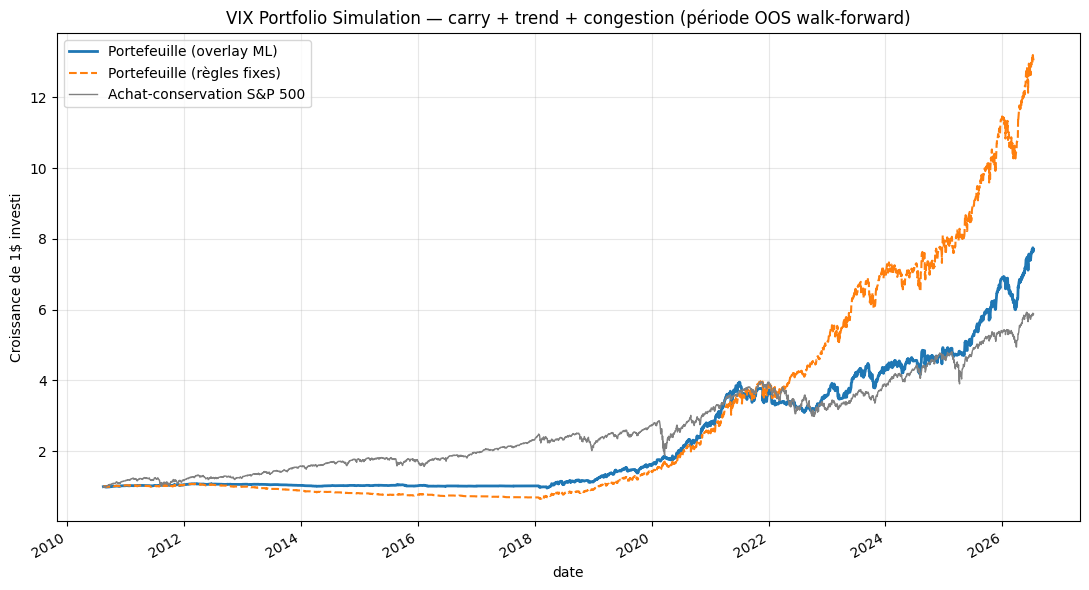

[SAVE] vix_portfolio_equity_curve.png
[SAVE] VIX_PORTFOLIO_SIM_report.xlsx


In [9]:
# ============================================================
# COURBES DE PERFORMANCE + EXPORT
# ============================================================
fig, ax = plt.subplots(figsize=(11, 6))
(1 + sleeves['portfolio_ret_ml']).cumprod().plot(ax=ax, label='Portefeuille (overlay ML)', linewidth=2)
(1 + sleeves['portfolio_ret_naive']).cumprod().plot(ax=ax, label='Portefeuille (règles fixes)', linewidth=1.5, linestyle='--')
(1 + sleeves['spx_ret']).cumprod().plot(ax=ax, label='Achat-conservation S&P 500', linewidth=1, color='gray')
ax.set_title('VIX Portfolio Simulation — carry + trend + congestion (période OOS walk-forward)')
ax.set_ylabel('Croissance de 1$ investi')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('vix_portfolio_equity_curve.png', dpi=120)
plt.show()
print("[SAVE] vix_portfolio_equity_curve.png")

try:
    with pd.ExcelWriter('VIX_PORTFOLIO_SIM_report.xlsx', engine='xlsxwriter') as writer:
        perf_df.to_excel(writer, 'Performance', index=False)
        sleeves.to_excel(writer, 'Detail_quotidien')
        oos_df.to_excel(writer, 'Predictions_OOS')
    print("[SAVE] VIX_PORTFOLIO_SIM_report.xlsx")
except Exception as e:
    print(f"[WARN Export] {e}")


In [10]:
# ============================================================
# PUSH DES RÉSULTATS (xlsx + courbe) SUR results/vix-portfolio-sim
# ============================================================
def push_results():
    if not GITHUB_TOKEN:
        print("[SKIP] Pas de GITHUB_TOKEN — les résultats ci-dessus restent valables localement.")
        return
    workdir = "/content/_vix_portfolio_push"
    try:
        subprocess.run(["rm", "-rf", workdir], check=False)
        url = f"https://{GITHUB_TOKEN}@github.com/{GITHUB_REPO}.git"
        clone = subprocess.run(["git", "clone", url, workdir], capture_output=True, text=True)
        if clone.returncode != 0:
            print(f"[WARN] clone: {clone.stderr[-300:]}"); return
        exists = subprocess.run(["git", "-C", workdir, "ls-remote", "--exit-code", "--heads",
                                  "origin", RESULTS_BRANCH], capture_output=True, text=True)
        if exists.returncode == 0:
            subprocess.run(["git", "-C", workdir, "checkout", "-B", RESULTS_BRANCH,
                             f"origin/{RESULTS_BRANCH}"], check=True)
        else:
            subprocess.run(["git", "-C", workdir, "checkout", "-B", RESULTS_BRANCH], check=True)
        for fn in ['VIX_PORTFOLIO_SIM_report.xlsx', 'vix_portfolio_equity_curve.png']:
            if os.path.exists(fn):
                subprocess.run(["cp", fn, f"{workdir}/{fn}"], check=True)
        subprocess.run(["git", "-C", workdir, "config", "user.email", "vix-colab@users.noreply.github.com"], check=True)
        subprocess.run(["git", "-C", workdir, "config", "user.name", "VIX Portfolio Sim Colab run"], check=True)
        subprocess.run(["git", "-C", workdir, "add", "VIX_PORTFOLIO_SIM_report.xlsx", "vix_portfolio_equity_curve.png"], check=True)
        subprocess.run(["git", "-C", workdir, "commit", "-m",
                       f"Résultats Portfolio Sim — {pd.Timestamp.now():%Y-%m-%d %H:%M}"],
                       capture_output=True, text=True)
        push = subprocess.run(["git", "-C", workdir, "push", "origin", RESULTS_BRANCH],
                              capture_output=True, text=True)
        if push.returncode == 0:
            print(f"[PUSH OK] Résultats sur '{RESULTS_BRANCH}'")
        else:
            print(f"[WARN] {push.stderr[-300:]}")
    except Exception as e:
        print(f"[WARN] {e}")

push_results()


[PUSH OK] Résultats sur 'results/vix-portfolio-sim'
